## Лабораторная работа: «Алгоритм Гриффина-Лима»

Выполнила: Перминова Анастасия, М4121

* Загрузка библиотек

In [239]:
import numpy as np
import librosa
from IPython.display import Audio
import matplotlib.pyplot as plt
from scipy import signal

* Загрузка и первичный анализ сигнала

In [240]:
audio, sr = librosa.load('voice.wav', sr=None)
print('\n')
print(f"Частота дискретизации: {sr} Гц")
print(f"Длина сигнала: {len(audio)} отсчетов")
print(f"Длительность: {len(audio)/sr:.2f} сек")
print('\n')
display(Audio(audio, rate=sr))



Частота дискретизации: 22050 Гц
Длина сигнала: 123275 отсчетов
Длительность: 5.59 сек




* Фильтр усиления высоких частот (Pre-emphasis фильтр)

In [241]:
y = np.append(audio[0], audio[1:] - 0.97 * audio[:-1])  # по формуле

* Вычисление STFT и построение спектрограммы

In [257]:
# определяем параметры STFT
N = 1024  # размер окна ДПФ (значение подобрано эмпирически)
hop_length = N // 4  # шаг между окнами (перекрытие 75%)

# вычисляем STFT
Y = librosa.stft(y, n_fft=N, hop_length=hop_length)

# вычисляем спектрограмму
D = np.abs(Y)

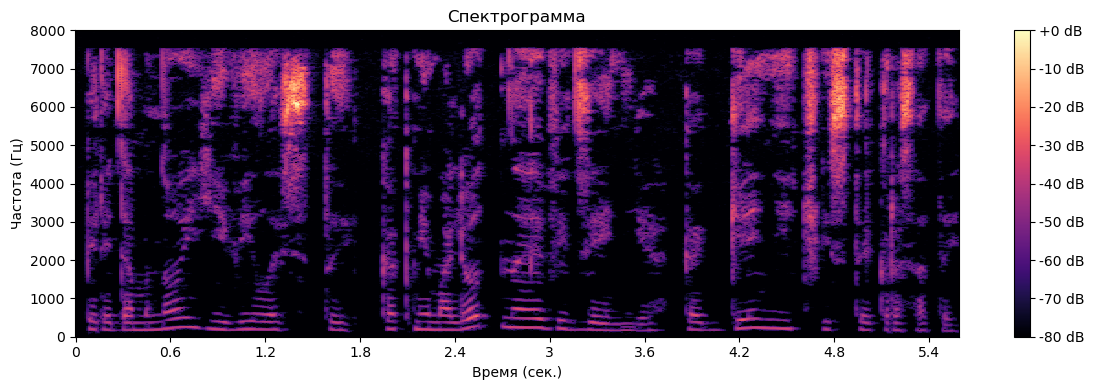

In [258]:
# визуализируем спектрограмму
plt.figure(figsize=(12, 4))
librosa.display.specshow(librosa.amplitude_to_db(D, ref=np.max),
                         sr=sr, hop_length=hop_length,
                         x_axis='time', y_axis='linear')
plt.ylabel('Частота (Гц)')
plt.xlabel('Время (сек.)')
plt.ylim([0, 8000])
plt.colorbar(format='%+2.0f dB')
plt.title('Спектрограмма')
plt.tight_layout()
plt.show()

* Реализация алгоритма Гриффина-Лима

In [259]:
def griffin_lim(D, n_iter=n_iterations, n_fft=N, hop_length=hop_length):

    # инициализация (случайная фаза)
    phase = np.random.uniform(-np.pi, np.pi, size=D.shape)
    Y_complex = D * np.exp(1j * phase)
    
    for i in range(n_iter):
        # реконструкция (обратное STFT)
        audio_recon = librosa.istft(Y_complex, hop_length=hop_length, win_length=n_fft)  # частотная область >> временная
        
        # прямое STFT (переводим восстановленный сигнал в частотную область)
        Y_new = librosa.stft(audio_recon, n_fft=n_fft, hop_length=hop_length, win_length=n_fft)
        
        # новая фаза
        phase_new = np.angle(Y_new)
        
        # обновление фазы
        Y_complex = D * np.exp(1j * phase_new)
    
    # финальное обратное преобразование (во временную область)
    audio_result = librosa.istft(Y_complex, hop_length=hop_length, win_length=n_fft)
    return audio_result

# применение алгоритма
n_iterations = 128
reconstructed_audio = griffin_lim(D, n_iter=n_iterations, n_fft=N, hop_length=hop_length)

* De-Emphasis

In [260]:
audio_de = signal.lfilter([1], [1, -0.97], reconstructed_audio)

* Сохранение и воспроизведение нового сигнала

In [261]:
output_file = 'voice_reconstructed.wav'
sf.write(output_file, audio_de, sr)

display(Audio(audio_de, rate=sr))